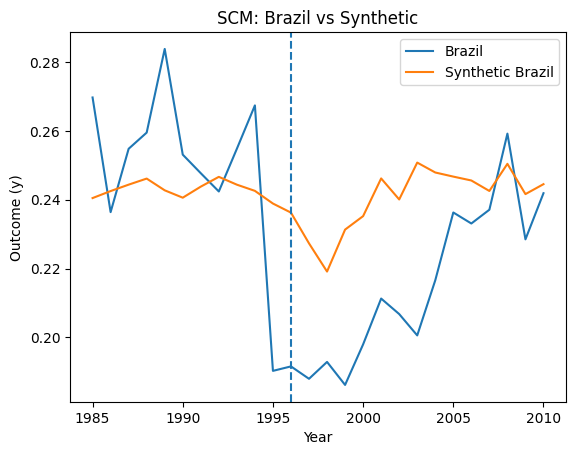

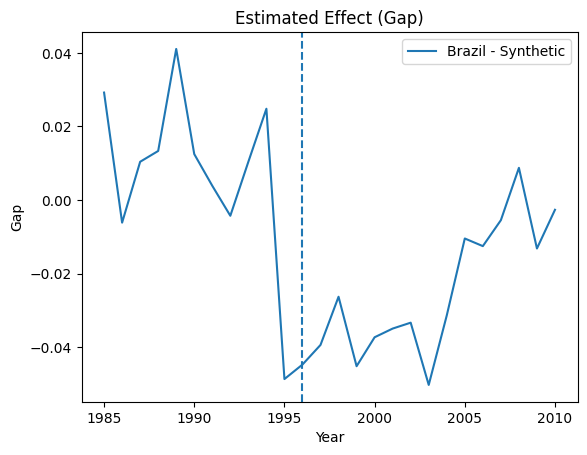

Top donor weights:
Thailand        6.723488e-01
Botswana        3.276512e-01
Grenada        -2.104619e-20
Dominica       -2.104619e-20
Burkina Faso   -3.427237e-20
Iran           -4.662422e-20
Philippines    -4.977389e-20
Malaysia       -5.824703e-20
Kenya          -6.066932e-20
Israel         -6.690535e-20
Niger          -8.221322e-20
Sri Lanka      -8.654042e-20
Egypt          -8.770898e-20
Hong Kong      -9.520346e-20
Pakistan       -9.566420e-20
dtype: float64


In [10]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
# -----------------------
# 1) LOAD + PREP DATA
# -----------------------
df = pd.read_csv(path+ "MASTER_FINAL.csv")  # columns: country, year, y
df = df.sort_values(["Country Name", "Year"])
df = df[(df['Year'] >= 1985) & (df['Year'] <= 2010)]
treated_unit = "Brazil"
treat_year = 1996  # your treatment year

# Optional: drop problematic year(s)
# df = df[~df["year"].isin([1994, 1995])]

# Keep a balanced-ish panel for SCM years
years = sorted(df["Year"].unique())
pre_years = [y for y in years if y < treat_year]
post_years = [y for y in years if y >= treat_year]

# Pivot to matrix: rows=years, cols=countries
Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

# Drop countries with missing values in the pre-period (simple, conservative)
pre_mask = Y.loc[pre_years].notna().all(axis=0)
Y = Y.loc[:, pre_mask]

if treated_unit not in Y.columns:
    raise ValueError(f"{treated_unit} not in columns after cleaning. Available: {list(Y.columns)[:10]}...")

donors = [c for c in Y.columns if c != treated_unit]
Y1 = Y[treated_unit]          # Brazil series (all years)
Y0 = Y[donors]                # donor matrix (all years)

# Pre-treatment matrices for fitting weights
X1 = Y0.loc[pre_years].values  # donors in pre
y1 = Y1.loc[pre_years].values  # brazil in pre

# -----------------------
# 2) SCM OPTIMIZATION
#    Choose weights w to match pre-treatment path
#    min ||y1 - X1 w||^2
#    s.t. w>=0, sum(w)=1
# -----------------------
w = cp.Variable(len(donors))

objective = cp.Minimize(cp.sum_squares(y1 - X1 @ w))
constraints = [w >= 0, cp.sum(w) == 1]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)  # OSQP usually works well; try SCS if needed

if w.value is None:
    raise RuntimeError("Optimization failed. Try solver=cp.SCS or check missing data.")

weights = pd.Series(np.array(w.value).ravel(), index=donors).sort_values(ascending=False)

# -----------------------
# 3) BUILD SYNTHETIC + EFFECT
# -----------------------
synthetic = (Y0.values @ np.array(w.value).ravel())
synthetic = pd.Series(synthetic, index=Y.index, name="Synthetic")

effect = Y1 - synthetic

# -----------------------
# 4) PLOTS
# -----------------------
plt.figure()
plt.plot(Y.index, Y1.values, label="Brazil")
plt.plot(Y.index, synthetic.values, label="Synthetic Brazil")
plt.axvline(treat_year, linestyle="--")
plt.title("SCM: Brazil vs Synthetic")
plt.xlabel("Year")
plt.ylabel("Outcome (y)")
plt.legend()
plt.show()

plt.figure()
plt.plot(effect.index, effect.values, label="Brazil - Synthetic")
plt.axvline(treat_year, linestyle="--")
plt.title("Estimated Effect (Gap)")
plt.xlabel("Year")
plt.ylabel("Gap")
plt.legend()
plt.show()

# -----------------------
# 5) OUTPUT TOP DONOR WEIGHTS
# -----------------------
print("Top donor weights:")
print(weights.head(15))

Countries to drop: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Brazil', 'Bulgaria', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Chad', 'Chile', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Cuba', 'DR Congo', 'Djibouti', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Georgia', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Iraq', 'Jamaica', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Lebanon', 'Liberia', 'Libya', 'Malawi', 'Maldives', 'Malta', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nicaragua', 'Oman', 'Palestine', 'Panama', 'Papua New Guinea', 'Paraguay', 'Peru', 'Qatar', 'Rwanda', 'Sao Tome and Principe', 'Saudi Arabia', 'Senegal', 'Seychelles', 'Sierra Leone', 'South Sudan', 'Sudan', 'Suriname', 'Syrian Arab Republic', 'Tajikistan', 'Timor-Leste', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkmeni

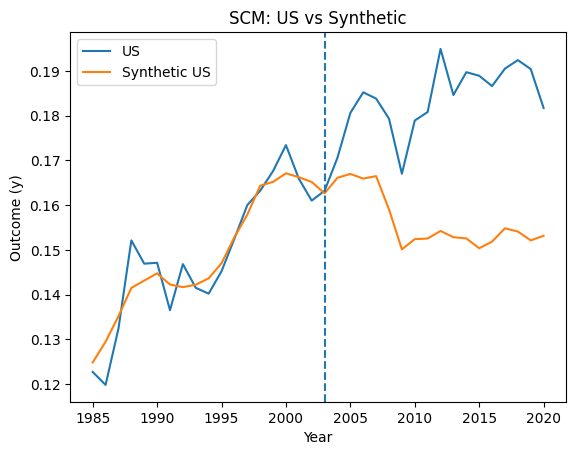

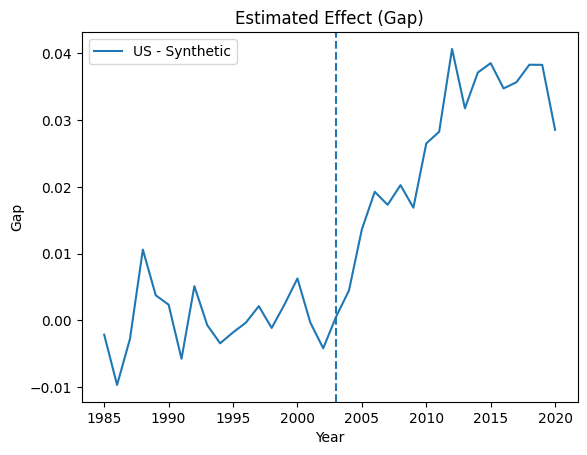

Top donor weights:
Sri Lanka             3.089419e-01
Germany               1.623899e-01
Nepal                 1.571505e-01
Burkina Faso          1.238639e-01
Australia             8.319765e-02
Luxembourg            6.920324e-02
Finland               6.915025e-02
Russian Federation    2.017321e-02
Malawi                5.929401e-03
Kyrgyzstan            1.062621e-18
Philippines           9.788893e-19
Cyprus                9.408461e-19
Estonia               8.433292e-19
Georgia               7.573634e-19
Romania               6.635281e-19
dtype: float64


In [17]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
# -----------------------
# 1) LOAD + PREP DATA
# -----------------------
df = pd.read_csv(path+ "scm_usa.csv")  # columns: country, year, y
eligible_countries = (
    df.loc[(df["Year"] <= 1985) & (df["top1_inc"].notna()), "Country Name"]
    .unique()
)
df = df[df["Country Name"].isin(eligible_countries)]
comparison = df[df['Year'].isin([1994, 1995])].pivot(index='Country Name', columns='Year', values='top1_inc')

countries_to_drop = comparison[comparison[1994] == comparison[1995]].index.tolist()

print("Countries to drop:", countries_to_drop)
df = df.sort_values(["Country Name", "Year"])
df = df[(df['Year'] >= 1985) & (df['Year'] <= 2020)]

treated_unit = "United States"
treat_year = 2003 # your treatment year

# Optional: drop problematic year(s)
# df = df[~df["year"].isin([1994, 1995])]

# Keep a balanced-ish panel for SCM years
years = sorted(df["Year"].unique())
pre_years = [y for y in years if y < treat_year]
post_years = [y for y in years if y >= treat_year]

# Pivot to matrix: rows=years, cols=countries
Y = df.pivot(index="Year", columns="Country Name", values="top1_inc").sort_index()

# Drop countries with missing values in the pre-period (simple, conservative)
pre_mask = Y.loc[pre_years].notna().all(axis=0)
Y = Y.loc[:, pre_mask]

if treated_unit not in Y.columns:
    raise ValueError(f"{treated_unit} not in columns after cleaning. Available: {list(Y.columns)[:10]}...")

donors = [c for c in Y.columns if c != treated_unit]
Y1 = Y[treated_unit]          # Brazil series (all years)
Y0 = Y[donors]                # donor matrix (all years)

# Pre-treatment matrices for fitting weights
X1 = Y0.loc[pre_years].values  # donors in pre
y1 = Y1.loc[pre_years].values  # brazil in pre

# -----------------------
# 2) SCM OPTIMIZATION
#    Choose weights w to match pre-treatment path
#    min ||y1 - X1 w||^2
#    s.t. w>=0, sum(w)=1
# -----------------------
w = cp.Variable(len(donors))

objective = cp.Minimize(cp.sum_squares(y1 - X1 @ w))
constraints = [w >= 0, cp.sum(w) == 1]

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.OSQP)  # OSQP usually works well; try SCS if needed

if w.value is None:
    raise RuntimeError("Optimization failed. Try solver=cp.SCS or check missing data.")

weights = pd.Series(np.array(w.value).ravel(), index=donors).sort_values(ascending=False)

# -----------------------
# 3) BUILD SYNTHETIC + EFFECT
# -----------------------
synthetic = (Y0.values @ np.array(w.value).ravel())
synthetic = pd.Series(synthetic, index=Y.index, name="Synthetic")

effect = Y1 - synthetic

# -----------------------
# 4) PLOTS
# -----------------------
plt.figure()
plt.plot(Y.index, Y1.values, label="US")
plt.plot(Y.index, synthetic.values, label="Synthetic US")
plt.axvline(treat_year, linestyle="--")
plt.title("SCM: US vs Synthetic")
plt.xlabel("Year")
plt.ylabel("Outcome (y)")
plt.legend()
plt.show()

plt.figure()
plt.plot(effect.index, effect.values, label="US - Synthetic")
plt.axvline(treat_year, linestyle="--")
plt.title("Estimated Effect (Gap)")
plt.xlabel("Year")
plt.ylabel("Gap")
plt.legend()
plt.show()

# -----------------------
# 5) OUTPUT TOP DONOR WEIGHTS
# -----------------------
print("Top donor weights:")
print(weights.head(15))

In [5]:
print("Sum of ALL weights:", weights.sum())
print("Min weight:", weights.min())
print("Any negative weights?", (weights < -1e-10).any())
print("Sum of top 15 weights:", weights.head(15).sum())
print("Number of donors:", len(weights))
print("Number of ~zero weights (<1e-8):", (weights.abs() < 1e-8).sum())

Sum of ALL weights: 0.9999999999999997
Min weight: -6.239993350120175e-19
Any negative weights? False
Sum of top 15 weights: 0.9999999999999997
Number of donors: 48
Number of ~zero weights (<1e-8): 41
